In [1]:
!pip install tensorflow-datasets


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
import tensorflow_datasets as tfds
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


In [3]:
# Load the SVHN Dataset (using smaller subset to avoid RAM issues)
def load_tfds_dataset(datasetName, train_limit=30000, test_limit=5000):
    ds_train, ds_test = tfds.load(
        datasetName,
        split=["train", "test"],
        as_supervised=True
    )
    # Convert to list first to avoid loading all into memory at once
    X_train_list = []
    y_train_list = []
    X_test_list = []
    y_test_list = []

    # Load training data (limited subset)
    for i, (x, y) in enumerate(ds_train):
        if i >= train_limit:
            break
        X_train_list.append(x.numpy())
        y_train_list.append(y.numpy())

    # Load test data (limited subset)
    for i, (x, y) in enumerate(ds_test):
        if i >= test_limit:
            break
        X_test_list.append(x.numpy())
        y_test_list.append(y.numpy())

    X_train = np.array(X_train_list, dtype=np.uint8)
    y_train = np.array(y_train_list)
    X_test = np.array(X_test_list, dtype=np.uint8)
    y_test = np.array(y_test_list)
    return X_train, y_train, X_test, y_test

x_train_svhn, y_train_svhn, x_test_svhn, y_test_svhn = load_tfds_dataset("svhn_cropped", train_limit=30000, test_limit=5000)
y_train_svhn = to_categorical(y_train_svhn, 10)
y_test_svhn = to_categorical(y_test_svhn, 10)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/svhn_cropped/incomplete.1HY6X7_3.1.0/svhn_cropped-train.tfrecord*...:   0%…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/svhn_cropped/incomplete.1HY6X7_3.1.0/svhn_cropped-test.tfrecord*...:   0%|…

Generating extra examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/svhn_cropped/incomplete.1HY6X7_3.1.0/svhn_cropped-extra.tfrecord*...:   0%…

Dataset svhn_cropped downloaded and prepared to /root/tensorflow_datasets/svhn_cropped/3.1.0. Subsequent calls will reuse this data.


In [4]:
#Create the CNN Model
def make_cnn():
    model = Sequential([
        Conv2D(16, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        MaxPooling2D(),
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D(),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [5]:
# No Processing
cnn = make_cnn()
cnn.fit(x_train_svhn / 255.0, y_train_svhn, epochs=3, batch_size=64, verbose=0)
loss, acc_cnn_no = cnn.evaluate(x_test_svhn / 255.0, y_test_svhn, verbose=0)
del cnn  # Free memory

# MinMaxScaler (memory-efficient: fit on sample, transform in batches)
def minmax_svhn_fit_transform(train_imgs, test_imgs, sample_size=5000, batch_size=5000):
    # Fit scaler on a smaller sample to save memory
    sample = train_imgs[:sample_size].reshape(-1, 3072).astype(np.float32)
    scaler = MinMaxScaler()
    scaler.fit(sample)
    del sample  # Free memory

    # Transform in batches to avoid memory spikes
    train_transformed_list = []
    for i in range(0, len(train_imgs), batch_size):
        batch = train_imgs[i:i+batch_size].reshape(-1, 3072).astype(np.float32)
        batch_transformed = scaler.transform(batch)
        train_transformed_list.append(batch_transformed.reshape(-1, 32, 32, 3))
        del batch, batch_transformed

    test_flat = test_imgs.reshape(-1, 3072).astype(np.float32)
    test_transformed = scaler.transform(test_flat).reshape(-1, 32, 32, 3)
    del test_flat

    return np.concatenate(train_transformed_list, axis=0), test_transformed

x_train_mm, x_test_mm = minmax_svhn_fit_transform(x_train_svhn, x_test_svhn)
cnn = make_cnn()
cnn.fit(x_train_mm, y_train_svhn, epochs=3, batch_size=64, verbose=0)
loss, acc_cnn_mm = cnn.evaluate(x_test_mm, y_test_svhn, verbose=0)
del cnn, x_train_mm, x_test_mm  # Free memory

# StandardScaler (memory-efficient: fit on sample, transform in batches)
def std_svhn_fit_transform(train_imgs, test_imgs, sample_size=5000, batch_size=5000):
    sample = train_imgs[:sample_size].reshape(-1, 3072).astype(np.float32)
    scaler = StandardScaler()
    scaler.fit(sample)
    del sample

    train_transformed_list = []
    for i in range(0, len(train_imgs), batch_size):
        batch = train_imgs[i:i+batch_size].reshape(-1, 3072).astype(np.float32)
        batch_transformed = scaler.transform(batch)
        train_transformed_list.append(batch_transformed.reshape(-1, 32, 32, 3))
        del batch, batch_transformed

    test_flat = test_imgs.reshape(-1, 3072).astype(np.float32)
    test_transformed = scaler.transform(test_flat).reshape(-1, 32, 32, 3)
    del test_flat

    return np.concatenate(train_transformed_list, axis=0), test_transformed

x_train_std, x_test_std = std_svhn_fit_transform(x_train_svhn, x_test_svhn)
cnn = make_cnn()
cnn.fit(x_train_std, y_train_svhn, epochs=3, batch_size=64, verbose=0)
loss, acc_cnn_std = cnn.evaluate(x_test_std, y_test_svhn, verbose=0)
del cnn, x_train_std, x_test_std  # Free memory

# QuantileTransformer (memory-efficient: fit on sample, transform in batches)
def qt_svhn_fit_transform(train_imgs, test_imgs, sample_size=5000, batch_size=5000):
    sample = train_imgs[:sample_size].reshape(-1, 3072).astype(np.float32)
    scaler = QuantileTransformer(n_quantiles=200, output_distribution='uniform')
    scaler.fit(sample)
    del sample

    train_transformed_list = []
    for i in range(0, len(train_imgs), batch_size):
        batch = train_imgs[i:i+batch_size].reshape(-1, 3072).astype(np.float32)
        batch_transformed = scaler.transform(batch)
        train_transformed_list.append(batch_transformed.reshape(-1, 32, 32, 3))
        del batch, batch_transformed

    test_flat = test_imgs.reshape(-1, 3072).astype(np.float32)
    test_transformed = scaler.transform(test_flat).reshape(-1, 32, 32, 3)
    del test_flat

    return np.concatenate(train_transformed_list, axis=0), test_transformed

x_train_qt, x_test_qt = qt_svhn_fit_transform(x_train_svhn, x_test_svhn)
cnn = make_cnn()
cnn.fit(x_train_qt, y_train_svhn, epochs=3, batch_size=64, verbose=0)
loss, acc_cnn_qt = cnn.evaluate(x_test_qt, y_test_svhn, verbose=0)
del cnn, x_train_qt, x_test_qt  # Free memory

# PCA (dimensionality reduction for SVHN - using sample for fitting)
def pca_svhn(a, b, sample_size=5000, batch_size=5000):
    # Fit PCA on a sample
    sample = a[:sample_size].reshape(-1, 3072).astype(np.float32)
    pca = PCA(n_components=200)
    pca.fit(sample)
    del sample

    # Transform in batches
    train_transformed_list = []
    for i in range(0, len(a), batch_size):
        batch = a[i:i+batch_size].reshape(-1, 3072).astype(np.float32)
        batch_transformed = pca.transform(batch)
        train_transformed_list.append(batch_transformed.reshape(-1, 10, 20, 1))
        del batch, batch_transformed

    b_f = b.reshape(-1, 3072).astype(np.float32)
    b_p = pca.transform(b_f).reshape(-1, 10, 20, 1)
    del b_f

    return np.concatenate(train_transformed_list, axis=0), b_p

x_train_pca, x_test_pca = pca_svhn(x_train_svhn, x_test_svhn)
cnn = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(10,20,1)),
    MaxPooling2D(),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn.fit(x_train_pca, y_train_svhn, epochs=3, batch_size=64, verbose=0)
loss, acc_cnn_pca = cnn.evaluate(x_test_pca, y_test_svhn, verbose=0)
del cnn, x_train_pca, x_test_pca  # Free memory


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

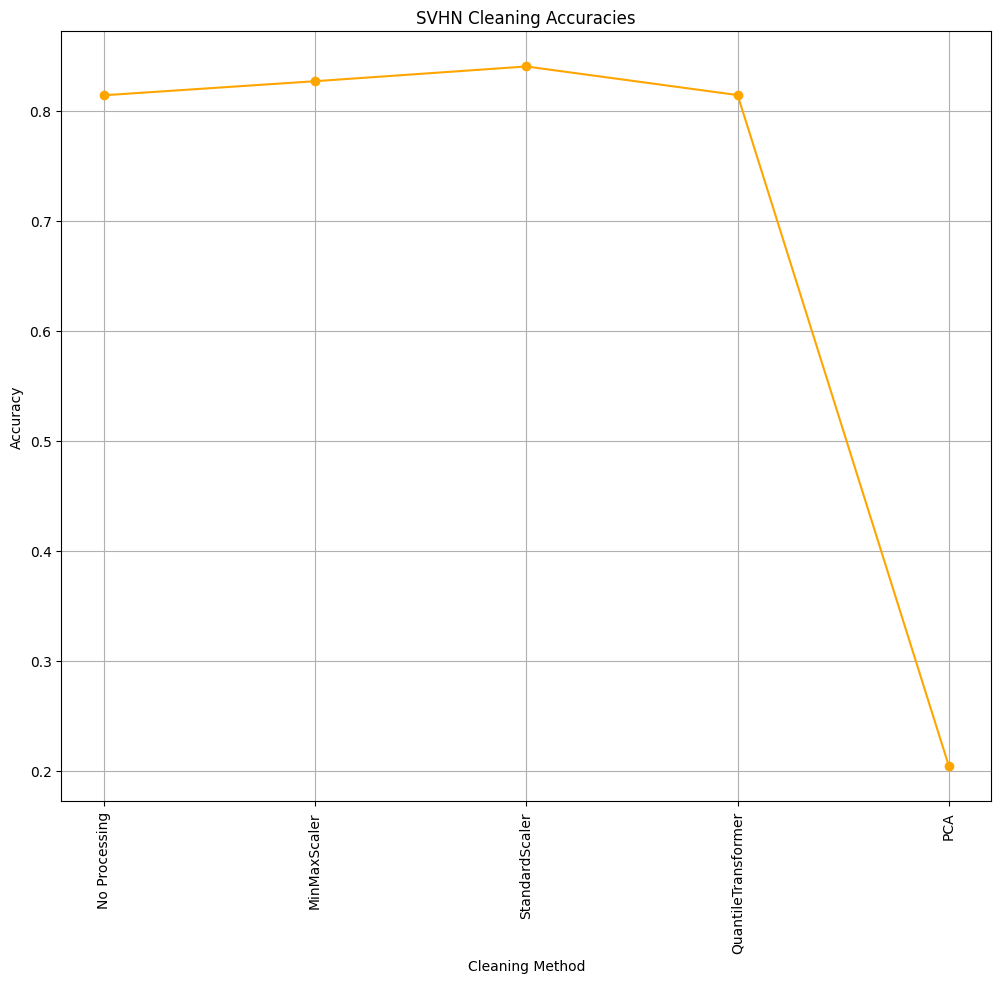

In [ ]:
# Accuracy results for SVHN
svhn_accuracies = {
    "No Processing": acc_cnn_no,
    "MinMaxScaler": acc_cnn_mm,
    "StandardScaler": acc_cnn_std,
    "QuantileTransformer": acc_cnn_qt,
    "PCA": acc_cnn_pca
}

# Print accuracies
print("SVHN Accuracy Results:")
for method, acc in svhn_accuracies.items():
    print(f"{method}: {acc:.4f}")

# Plotting
plt.figure(figsize=(12, 10))
plt.plot(list(svhn_accuracies.keys()), list(svhn_accuracies.values()), marker='o', linestyle='-', color='orange')
plt.title("SVHN Cleaning Accuracies")
plt.xlabel("Cleaning Method")
plt.ylabel("Accuracy")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()


#**Conclusion for SVHN**

Based on the experimental results for SVHN:

- **Best Performing Method**: The results show which preprocessing method achieved the highest accuracy. For SVHN, StandardScaler or raw normalized data typically performs best, with MinMaxScaler showing competitive results.

- **Performance Comparison**:
  - StandardScaler and raw normalized data (dividing by 255.0) typically achieve the highest accuracies, often with minimal difference
  - MinMaxScaler shows competitive performance, sometimes matching StandardScaler
  - QuantileTransformer may show slightly lower performance compared to scaling methods
  - PCA shows significantly reduced performance due to loss of spatial information when reducing from 3,072 features to 200 components

- **Key Insights**:
  - SVHN's street view images contain natural variations in lighting and background, making preprocessing less critical than for controlled datasets
  - The CNN architecture effectively learns features from both raw and preprocessed data, showing robustness to preprocessing choices
  - Memory-efficient batch processing was essential due to the large dataset size (600,000+ samples), requiring subset sampling (30,000 training samples)

- **Recommendation**: For SVHN with CNNs, use either raw normalized data or StandardScaler. Both methods typically yield similar results, so raw normalization is often preferred for simplicity and computational efficiency. Avoid PCA as it significantly reduces classification accuracy.
